<a href="https://colab.research.google.com/github/boodie04/Unsupervised-ML/blob/main/Enhanced_DBSCAN_With_K_means_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DBSCAN ASSIGNMENT

FIRST STEP IMPORT THE LIB.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN

GENERATR BOTH DATA


In [ ]:
# Generate datasets
X_spherical, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.6, random_state=0)
X_nonspherical, _ = make_moons(n_samples=500, noise=0.05, random_state=0)


Ready Plot Function.

In [ ]:
def plot_clusters(data, labels, title, core_samples_mask=None, noise_label=-1):
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each)
              for each in np.linspace(0, 1, len(unique_labels))]

    for k, col in zip(unique_labels, colors):
        if k == noise_label:
            col = [0, 0, 0, 1]  # Black for noise

        class_member_mask = (labels == k)

        if core_samples_mask is not None:
            xy = data[class_member_mask & core_samples_mask]
            plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                     markeredgecolor='k', markersize=10)

            xy = data[class_member_mask & ~core_samples_mask]
            plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                     markeredgecolor='k', markersize=6)
        else:
            xy = data[class_member_mask]
            plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                     markeredgecolor='k', markersize=6)

    plt.title(title)
    plt.grid(True)


enhanced_dbscan Function

partition = data[...]	Extracts points for one KMeans cluster

indices = np.where(...)	Gets original indices of those points

DBSCAN().fit(...)	Applies DBSCAN to the partition

labels = db.labels_	Gets local DBSCAN results

core_samples_mask[...] = True	Marks which points are core

Inner loop	Transfers labels to global array and updates core point mask

label_offset += ...	Ensures next cluster labels don’t overlap

In [ ]:
def enhanced_dbscan(data, k, eps, min_samples):
    # KMeans Partitioning
    kmeans = KMeans(n_clusters=k, random_state=0).fit(data)
    kmeans_labels = kmeans.labels_
#plot fig size
    plt.figure(figsize=(15, 4))
    # 1-row 3-column 1-the first from left
    plt.subplot(1, 3, 1)
    # data (2D nummpy array) np.zeros(data"2D arr",array of zeros of same length as data for all point to be same color, fig name)
    plot_clusters(data, np.zeros(len(data)), "Original Dataset")
# Activate the second subplot (middle panel). 1-row 3-column 2-second plot sec.column
    plt.subplot(1, 3, 2)
    #data (2D ARR , k-means labels for Diff colors , "k-means part...." <- fig name )
    plot_clusters(data, kmeans_labels, f"KMeans Partitioning (K={k})")

     # Apply DBSCAN per partition
     #Creates an array dbscan_labels with the same number of elements as your dataset.
      #Fills it with -1, which is the default label for noise in DBSCAN.

    dbscan_labels = np.full(shape=len(data), fill_value=-1)
    #Creates a boolean array with one value per point.
    #All values are initially False.
    core_samples_mask_total = np.full(shape=len(data), fill_value=False)
    #Initializes a counter used to make sure cluster labels from different partitions don’t overlap.
    label_offset = 0

    # process one partition at a time using its cluster_id.
    for cluster_id in range(k):
        #This extracts only the data points that belong to the current KMeans cluster.
        partition = data[kmeans_labels == cluster_id]
        #This gets the original indices of those points in the full dataset.
        #If you skip [0], you'd get a tuple, not a usable array:
        # np.where This returns a tuple of arrays — one for each dimension.
        # [0] is just getting the actual array of indices you want to work with.
        indices = np.where(kmeans_labels == cluster_id)[0]
        #Apply DBSCAN on the current KMeans partition.
        #eps = max distance between neighbors.
        #min_samples = minimum neighbors to be considered a core point.
        #partition is the current subset of points.
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(partition)
        #Get DBSCAN’s output labels for this partition.
        #Values will be:
        #0, 1, 2, ... for cluster IDs (in this partition only)
        #-1 for noise
        labels = db.labels_
        #Create a boolean array for this partition:
        #Same length as labels
        #All values False
        core_samples_mask = np.zeros_like(labels, dtype=bool)
        #Now you're marking which points in this partition are core points.
        #db.core_sample_indices_ gives indices of core points within this partition.
        #You update the core_samples_mask so those positions are True.
        core_samples_mask[db.core_sample_indices_] = True

        for i, idx in enumerate(indices):
            if labels[i] != -1:
                dbscan_labels[idx] = labels[i] + label_offset
                if core_samples_mask[i]:
                    core_samples_mask_total[idx] = True

        label_offset += len(set(labels)) - (1 if -1 in labels else 0)

    plt.subplot(1, 3, 3)
    plot_clusters(data, dbscan_labels, "Enhanced DBSCAN Clustering", core_samples_mask_total)
    plt.show()



In [ ]:
def standard_dbscan_border_detection(data, param_list):
    for eps, min_samples in param_list:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(data)
        labels = db.labels_

        core_mask = np.zeros_like(labels, dtype=bool)
        core_mask[db.core_sample_indices_] = True

        border_mask = (labels != -1) & (~core_mask)
        noise_mask = labels == -1

        reduction_ratio = np.sum(border_mask) / len(data)

        # Plotting
        plt.figure(figsize=(15, 4))

        plt.subplot(1, 3, 1)
        plot_clusters(data, np.zeros(len(data)), "Raw Dataset")

        plt.subplot(1, 3, 2)
        plot_clusters(data, labels, f"DBSCAN: eps={eps}, min_samples={min_samples}", core_mask)

        plt.subplot(1, 3, 3)
        plot_clusters(data[border_mask], labels[border_mask], f"Border Points Only\nReduction Ratio: {reduction_ratio:.2f}")

        plt.show()


Running Enhanced DBSCAN on Spherical Dataset


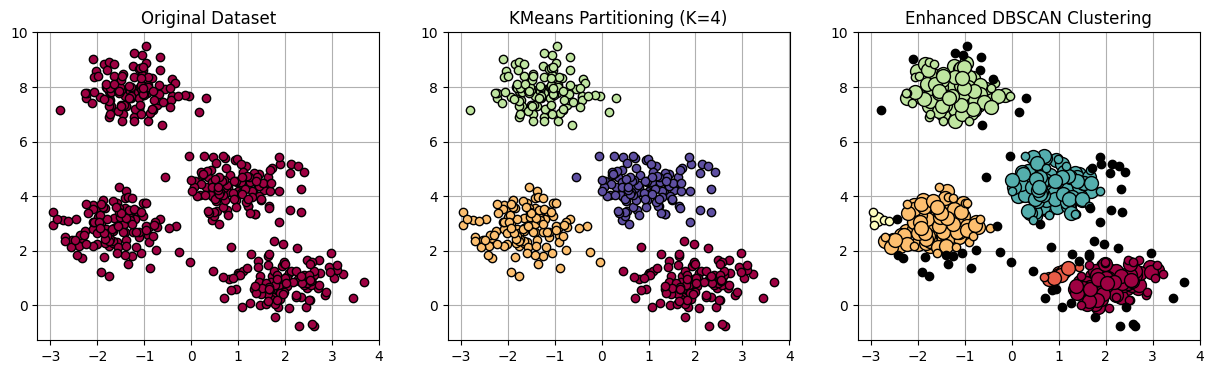

Running Enhanced DBSCAN on Non-Spherical Dataset


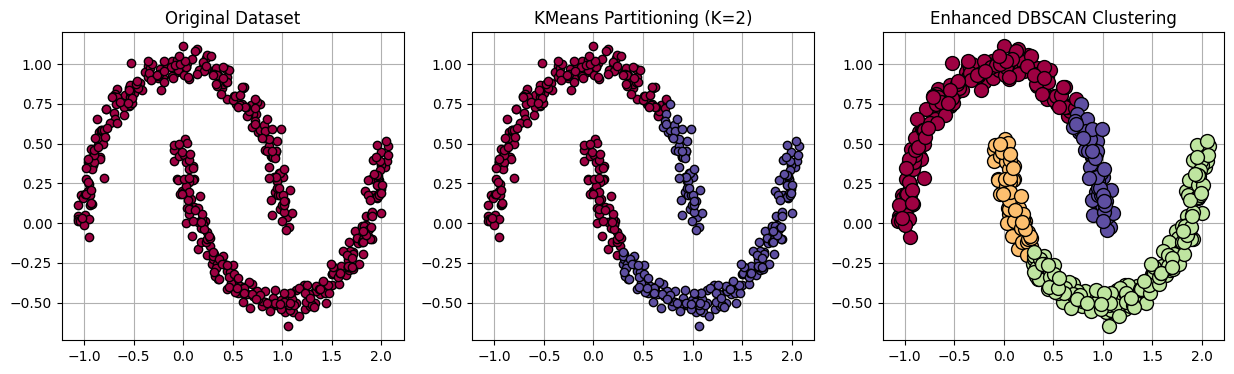

Running Standard DBSCAN + Border Detection on Spherical Dataset


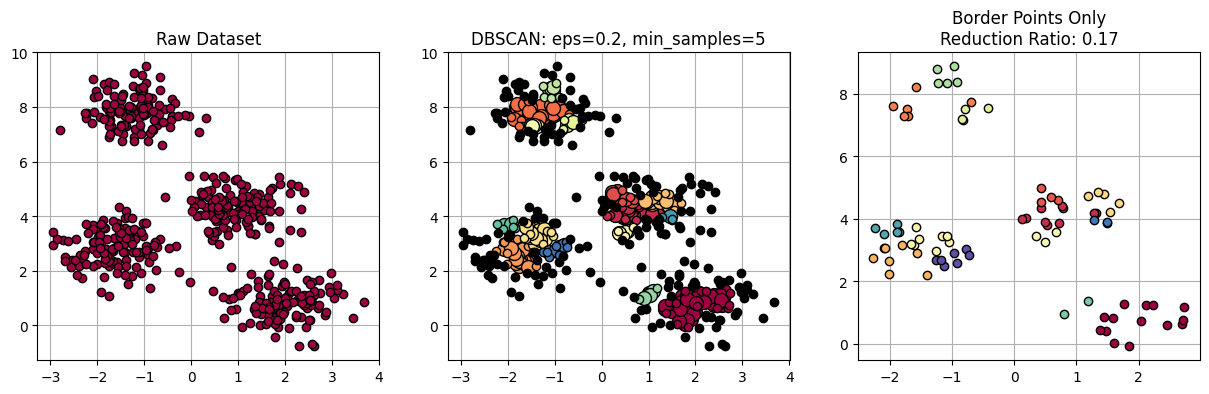

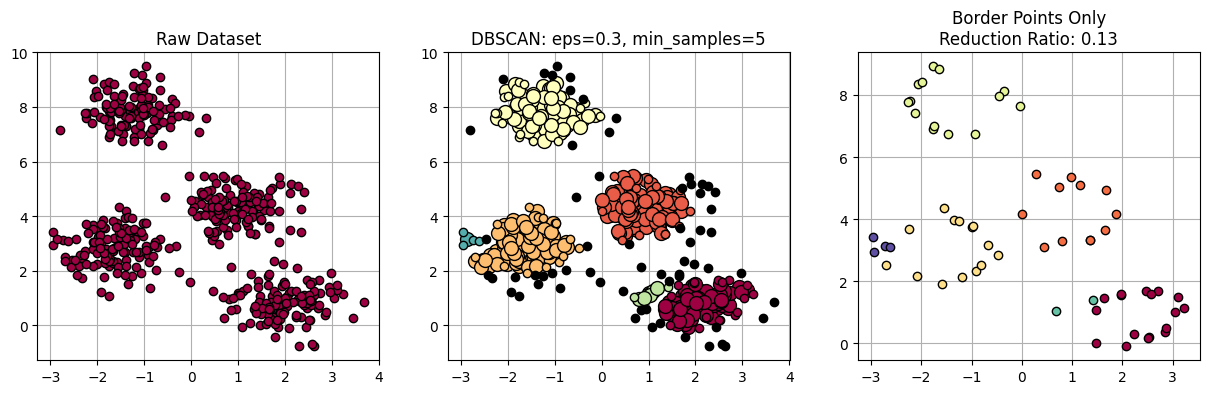

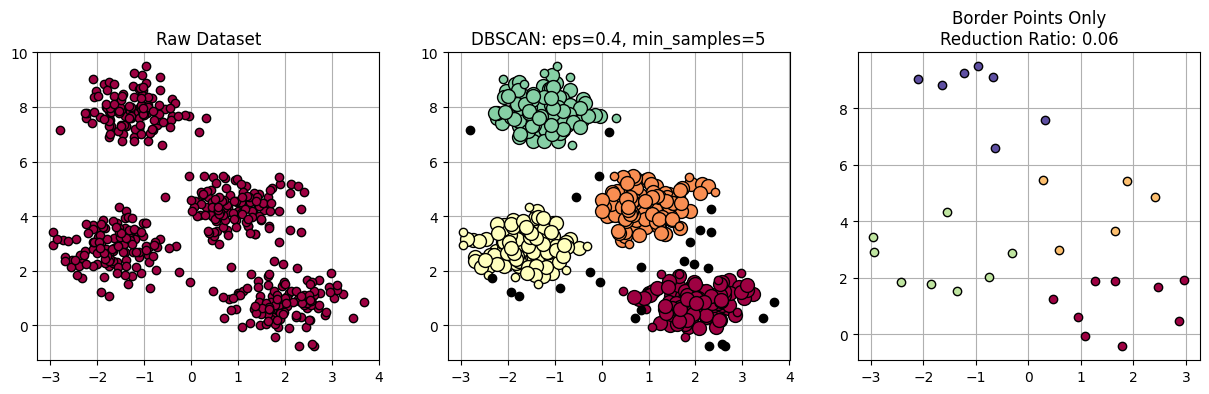

Running Standard DBSCAN + Border Detection on Non-Spherical Dataset


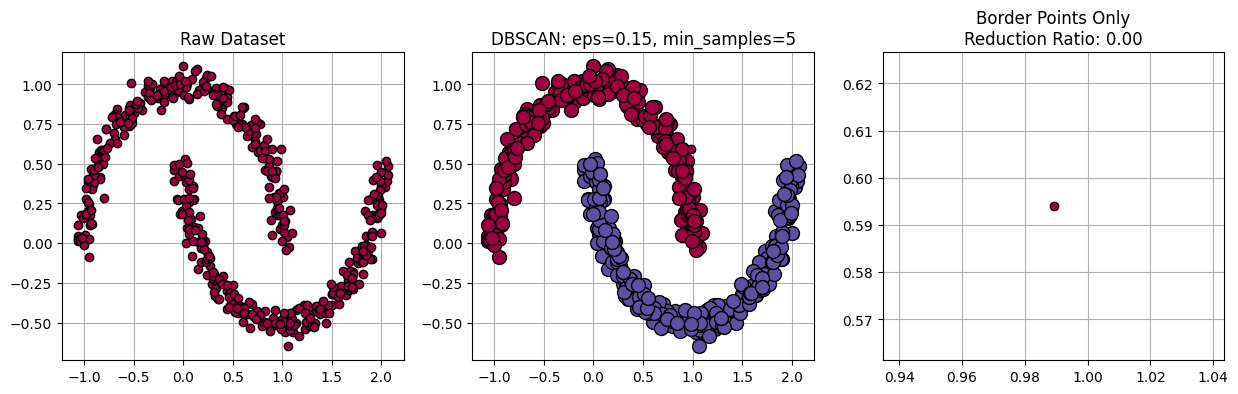

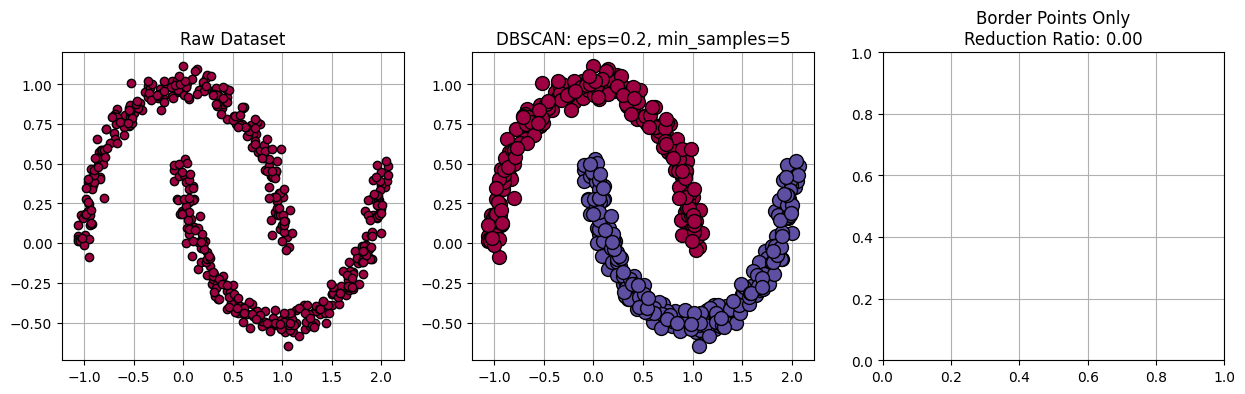

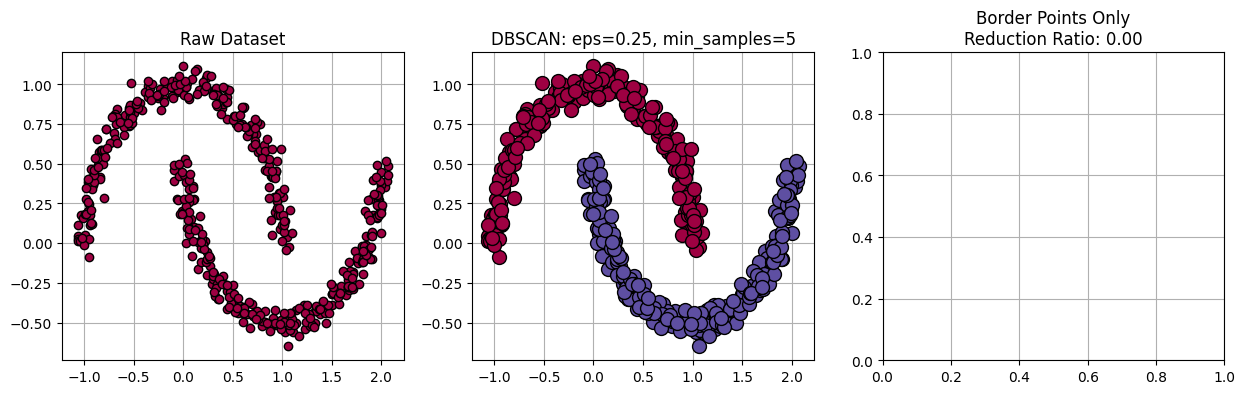

In [ ]:
# --- Run Examples ---
print("Running Enhanced DBSCAN on Spherical Dataset")
enhanced_dbscan(X_spherical, k=4, eps=0.3, min_samples=5)

print("Running Enhanced DBSCAN on Non-Spherical Dataset")
enhanced_dbscan(X_nonspherical, k=2, eps=0.2, min_samples=5)

print("Running Standard DBSCAN + Border Detection on Spherical Dataset")
standard_dbscan_border_detection(X_spherical, [(0.2, 5), (0.3, 5), (0.4, 5)])

print("Running Standard DBSCAN + Border Detection on Non-Spherical Dataset")
standard_dbscan_border_detection(X_nonspherical, [(0.15, 5), (0.2, 5), (0.25, 5)])
